IMPORTING REQUIRED MODULES

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import regex as re

# MANUAL INSPECTION
DATA DIRTINESS
- age has missing values -5 rows(on programmatic assessment)
- region has missing values -3 rows (on programmatic assessment)

In [ ]:
df=pd.read_csv(r'insurance_data.csv')

In [ ]:
df.info()

WE COULD HAVE CHANGED THE DATATYPE OF AGE COLUMN BUT SINCE SOME VALUES ARE MISSING WE CANNOT FILL IT UP ALTHOUGH WE CAN DROP IT AS ONLY 5 ROWS ARE THERE 

# CATEGORIZING THE COLUMNS
numerical-index,patientid,age,bmi,bloodpressure,claim

categorical-gender,diabetic,smoker,region,children

In [ ]:
df['children'].value_counts()

In [ ]:
df.duplicated().sum()

# UNIVARIATE ANALYSIS ON AGE COLUMN
## conclusions
- all 18 year old (min age) were males
- all 60 year olds(max age) were females
- age column is almost normally distributed
- age has no outlier
- all 53 year olds(the grp with least members) were females
- 5 age rows have no values

In [ ]:
df['age'].describe()

In [ ]:
df.query("age==18")
#all 18 year olds were male

In [ ]:
df.query("age==60")
#all 60 year(max age) olds were females

In [ ]:
df['age'].skew() #almost normally distributed

In [ ]:
df['age'].plot(kind='hist')

In [ ]:
sns.kdeplot(data=df,x='age')

In [ ]:
sns.boxplot(data=df, y='age')
plt.show()

In [ ]:
sns.violinplot(data=df, y='age')
plt.show()

In [ ]:
df['age'].isnull().sum()

In [ ]:
df['age'].value_counts()

In [ ]:
df.query('age==53')
#this is the age with least members and all are females

In [ ]:
df.query('age==38')

In [ ]:
df.query('age==47')

# UNIVARIATE ANALYSIS ON BMI COLUMN
## CONCLUSION
- THE PERSON WITH MAX BMI AND MIN BMI BOTH ARE MALES 
- THE DATA IS NORMALLY DISTRIBUTED
- THERE ARE SOME OUTLIERS
- NO NULL VALUES

In [ ]:
df['bmi'].describe()

In [ ]:
df.query('bmi==16')

In [ ]:
df.query('bmi==53.1')

In [ ]:
df['bmi'].plot(kind='hist')

In [ ]:
sns.kdeplot(data=df,x='bmi')

In [ ]:
df.bmi.skew()

In [ ]:
sns.boxplot(data=df,x='bmi')

In [ ]:
df.query('bmi>45')
#these are the outliers although they don't have any issues with them

In [ ]:
df['bmi'].value_counts()

In [ ]:
df.query('bmi==33.3')

In [ ]:
df['bmi'].duplicated().sum()

# UNIVARIATE ANALYSIS ON BLOODPRESSURE COLUMN
### CONCLUSIONS
- those with highest bloodpressure 140 had very high claims above 35k
- there were outliers above 118 bloodpressure and they also had very high claims
- the bloodpressure column is positively skewed

In [ ]:
df['bloodpressure'].describe()

In [ ]:
df.query('bloodpressure==80')

In [ ]:
df.query('bloodpressure==140')
#the people with 140 blood pressure had very high claims above 35k

In [ ]:
df['bloodpressure'].plot(kind='hist')

In [ ]:
sns.kdeplot(data=df,x='bloodpressure')

In [ ]:
sns.boxplot(data=df,y='bloodpressure')

In [ ]:
df.query('bloodpressure>118')
#there were outliers above 118 and all of them had very high claim

In [ ]:
df['bloodpressure'].skew()

In [ ]:
df['bloodpressure'].value_counts()

In [ ]:
df['bloodpressure'].isnull().sum()

# UNIVARIATE ANALYSIS ON CLAIM
### CONCLUSIONS
- the least claim is 1121.87 which is by a male
- the highest claim is by a female at 63770.43 who is a smoker
- the data is positively skewed
- there are outliers in this data i.e claims above 35k and on inspection we find that most of them were smokers only 3 weren't smokers and they were females (pid-->1210,1223)
- also when we check those claims above 75 percentile most of them were smokers 

In [103]:
df['claim'].describe()

count     1340.000000
mean     13252.745642
std      12109.609288
min       1121.870000
25%       4719.685000
50%       9369.615000
75%      16604.305000
max      63770.430000
Name: claim, dtype: float64

In [104]:
df.query('claim==1121.87')

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87


In [105]:
df.query('claim==63770.43')

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
1339,1339,1340,30.0,female,47.4,101,No,0,Yes,southeast,63770.43


<Axes: ylabel='Frequency'>

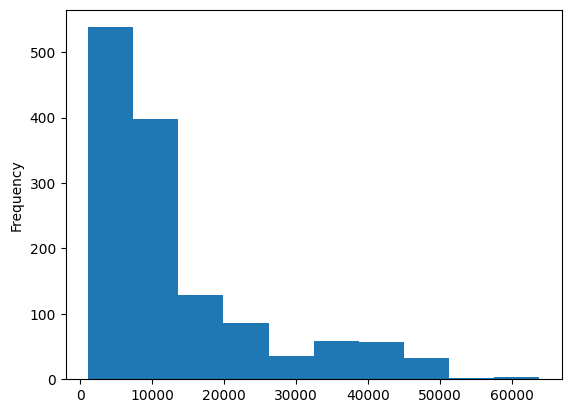

In [106]:
df.claim.plot(kind='hist')

In [107]:
df.claim.skew()

np.float64(1.5167468509489237)

<Axes: xlabel='claim', ylabel='Density'>

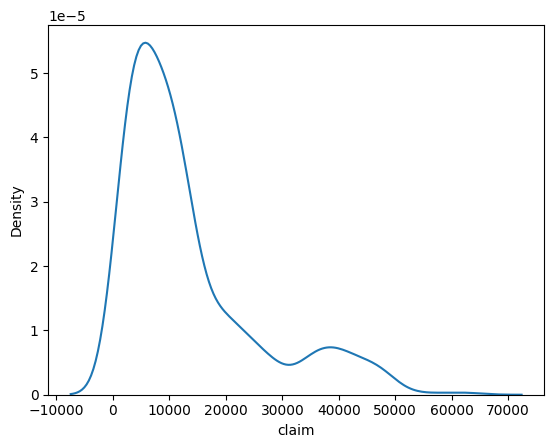

In [108]:
sns.kdeplot(data=df,x='claim')

<Axes: ylabel='claim'>

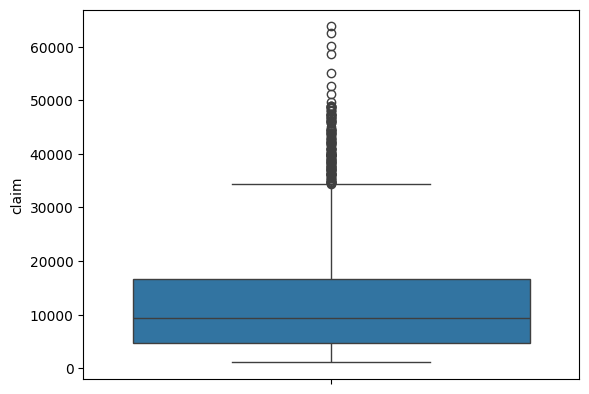

In [109]:
sns.boxplot(data=df,y='claim')

In [112]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df.query('claim > 35000')

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
1207,1207,1208,22.0,male,22.9,80,No,0,Yes,northeast,35069.37
1208,1208,1209,23.0,male,28.5,106,No,0,Yes,northeast,35147.53
1209,1209,1210,32.0,female,26.8,107,No,1,No,southwest,35160.13
1210,1210,1211,25.0,male,30.8,140,Yes,0,Yes,southwest,35491.64
1211,1211,1212,22.0,male,35.6,97,Yes,0,Yes,southwest,35585.58
1212,1212,1213,56.0,female,31.0,129,Yes,3,Yes,southeast,35595.59
1213,1213,1214,30.0,female,32.8,98,No,2,Yes,southeast,36021.01
1214,1214,1215,40.0,male,32.9,87,Yes,2,Yes,southwest,36085.22
1215,1215,1216,22.0,male,33.3,117,No,2,Yes,southeast,36124.57
1216,1216,1217,34.0,female,36.9,131,No,0,Yes,southeast,36149.48


In [111]:
df.claim.value_counts()

claim
1149.40     2
1639.56     2
1704.57     2
1121.87     1
1131.51     1
           ..
55135.40    1
58571.07    1
60021.40    1
62592.87    1
63770.43    1
Name: count, Length: 1337, dtype: int64

In [113]:
df.claim.isnull().sum()

np.int64(0)

In [116]:
df.query('claim>16604.305')['smoker'].value_counts()

smoker
Yes    255
No      80
Name: count, dtype: int64

In [117]:
df.query('claim > 35000')['smoker'].value_counts()

smoker
Yes    130
No       3
Name: count, dtype: int64